In [ ]:
!pip install torch torchvision torchaudio

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 3.0 MB/s  0:00:24m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.3/807.3 kB 3.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.8 MB/s  0:00:01 eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 4.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [torchaudio]2 [torchaudio]]


# Lab Practical 1

## Introduction of PyTorch Tensors and Basic Operations.
- a) To understand PyTorch tensors, their initialization methods, and data types.
- b) To perform tensor operations such as arithmetic, broadcasting, indexing, and
reshaping.
- c) To explore automatic differentiation using PyTorch’s Autograd system.

In [ ]:
import torch
import numpy as np
import sys # Import the sys module
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
# Print versions
print("torch version:", torch.__version__)
print("numpy version:", np.__version__)
print("python version: ",sys.version)

torch version: 2.9.1
numpy version: 2.4.1
python version:  3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]


## What are Tensors?

Tensor holds a multi-dimensional array of elements of a single data type which is very similar with numpy’s ndarray. When the dimension is zero, it can be called a scalar. When the dimension is 1, it can be called a vector. When the dimension is 2, it can be called a matrix.

- 0-dimensional tensor: A single number (scalar).
- 1-dimensional tensor: A list of numbers (vector).
- 2-dimensional tensor: A table of numbers (matrix).

When the dimension is greater than 2, it is usually called a tensor.

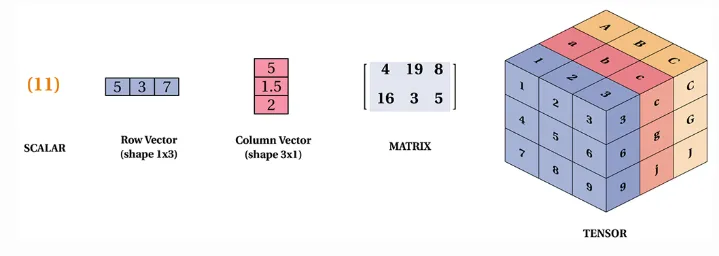

In [ ]:
# Check for CUDA availability and set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize a 2x3 tensor with requires_grad enabled Enables automatic differentiation for this tensor.
my_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32, device=device, requires_grad=True)

print(my_tensor)
print("Data type:", my_tensor.dtype)
print("Device:", my_tensor.device)
print("Shape:", my_tensor.shape)
print("Requires Gradient:", my_tensor.requires_grad)

tensor([[1., 2., 3.],
        [4., 5., 6.]], requires_grad=True)
Data type: torch.float32
Device: cpu
Shape: torch.Size([2, 3])
Requires Gradient: True


## Other Common Tensor Initialization Methods

- **Empty Tensor:** Creates an uninitialized 3×3 tensor (random values).
- **Zeros Tensor:** Creates a 3×3 tensor filled with zeros.
- **Random Tensor:** Generates a 3×3 tensor with random values between 0 and 1.
- **Ones Tensor:** Creates a 3×3 tensor filled with ones.
- **Identity Matrix:** Generates a 4×4 identity matrix (diagonal of ones).
- **Arange Tensor:** Creates a 1D tensor with values from 0 to 4 (step of 1).
- **Linspace Tensor:** Generates 5 evenly spaced values between 0.1 and 1.
- **Normal Distributed Tensor:** Fills a tensor with values from a normal (Gaussian) distribution with mean 0 and std 1.
- **Uniform Distributed Tensor:** Fills a tensor with values from a uniform distribution between 0 and 1.
- **Diagonal Tensor:** Creates a 4×4 diagonal tensor with ones along the diagonal and zeros elsewhere.

In [ ]:
# Create an empty tensor of size 3x3
x = torch.empty(3, 3)
print("Empty Tensor:\n", x)

# Create a tensor filled with zeros
x = torch.zeros(3, 3)
print("Zeros Tensor:\n", x)

# Create a tensor with random values
x = torch.rand(3, 3)
print("Random Tensor:\n", x)

# Create a tensor filled with ones
x = torch.ones(3, 3)
print("Ones Tensor:\n", x)

# Create an identity matrix
x = torch.eye(4, 4)
print("Identity Matrix:\n", x)

# Create a tensor using arange
x = torch.arange(5)
print("Arange Tensor:\n", x)

# Create a tensor using linspace
x = torch.linspace(0.1, 1, 5)
print("Linspace Tensor:\n", x)

# Create a tensor with values drawn from a normal distribution
x = torch.empty(1, 5).normal_(mean=0, std=1)
print("Normal Distributed Tensor:\n", x)

# Create a tensor with values drawn from a uniform distribution
x = torch.empty(1, 5).uniform_(0, 1)
print("Uniform Distributed Tensor:\n", x)

# Create a diagonal tensor from a tensor of ones
x = torch.diag(torch.ones(4))
print("Diagonal Tensor:\n", x)

Empty Tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
Zeros Tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
Random Tensor:
 tensor([[0.2570, 0.4106, 0.5193],
        [0.6959, 0.1368, 0.1122],
        [0.6667, 0.4440, 0.5579]])
Ones Tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
Identity Matrix:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])
Arange Tensor:
 tensor([0, 1, 2, 3, 4])
Linspace Tensor:
 tensor([0.1000, 0.3250, 0.5500, 0.7750, 1.0000])
Normal Distributed Tensor:
 tensor([[ 1.2181,  1.7386,  0.8587,  1.2526, -1.1569]])
Uniform Distributed Tensor:
 tensor([[0.9046, 0.2511, 0.8219, 0.8879, 0.2150]])
Diagonal Tensor:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


In [ ]:
# Create a tensor and convert its type
tensor = torch.arange(4)
print("Boolean Tensor:", tensor.bool())   # Convert to boolean
print("Short Tensor (int16):", tensor.short())   # Convert to int16
print("Long Tensor (int64):", tensor.long())   # Convert to int64
print("Half Tensor (float16):", tensor.half())   # Convert to float16
print("Float Tensor (float32):", tensor.float())   # Convert to float32
print("Double Tensor (float64):", tensor.double())   # Convert to float64

Boolean Tensor: tensor([False,  True,  True,  True])
Short Tensor (int16): tensor([0, 1, 2, 3], dtype=torch.int16)
Long Tensor (int64): tensor([0, 1, 2, 3])
Half Tensor (float16): tensor([0., 1., 2., 3.], dtype=torch.float16)
Float Tensor (float32): tensor([0., 1., 2., 3.])
Double Tensor (float64): tensor([0., 1., 2., 3.], dtype=torch.float64)


## Converting Between NumPy Arrays and Tensors

PyTorch makes it easy to switch between NumPy arrays and tensors, allowing seamless integration with existing computing workflows.

In [ ]:
# Create a NumPy array of zeros
np_array = np.zeros((5, 5))
print("NumPy Array:\n", np_array)
# Convert NumPy array to PyTorch tensor
tensor = torch.from_numpy(np_array)
print("Tensor from NumPy Array:\n", tensor)
# Convert tensor back to NumPy array
numpy_back = tensor.numpy()
print("Converted Back to NumPy Array:\n", numpy_back)

NumPy Array:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Tensor from NumPy Array:
 tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], dtype=torch.float64)
Converted Back to NumPy Array:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


## Tensor Mathematics and Comparison Operations

This section explores essential math operations with PyTorch tensors.

- **Addition & Subtraction:** Adds and subtracts two tensors element-wise.  
- **Division:** Uses true division for precise results.  
- **Inplace Operations:** Modifies a tensor directly without creating a new one.  
- **Exponentiation:** Raises each element to a power using `pow()` or `**`.  
- **Comparisons:** Checks conditions like `x > 0` or `x < 0`, returning boolean results.  
- **Dot Product:** Computes the sum of element-wise multiplications between two tensors.

In [ ]:
# Define two tensors for operations
x = torch.tensor([1, 2, 3])
y = torch.tensor([9, 8, 7])

# Addition
z = x + y
print("Addition Results:", z)

# Addition using .add
z1 = torch.empty(3)
torch.add(x, y, out=z1)
z2 = torch.add(x, y)
print("Addition Results:", z, z1, z2)

# Subtraction
z = x - y
print("Subtraction Result:", z)

# Division (true division)
z = torch.true_divide(x, y)
print("Division Result:", z)

# Inplace operations
t = torch.ones(3)
print("Before inplace addition:", t)
t.add_(x)
print("After inplace addition:", t)
t += x  # Another inplace addition (note: t = t + x creates a new tensor)
print("After second inplace addition:", t)

# Exponentiation
z = x.pow(2)
print("Exponentiation (pow):", z)
z = x**2
print("Exponentiation (**):", z)

# Comparisons
z = x > 0
print("x > 0:", z)
z = x < 0
print("x < 0:", z)

# Dot product
z = torch.dot(x, y)
print("Dot Product:", z)

Addition Results: tensor([10, 10, 10])
Addition Results: tensor([10, 10, 10]) tensor([10., 10., 10.]) tensor([10, 10, 10])
Subtraction Result: tensor([-8, -6, -4])
Division Result: tensor([0.1111, 0.2500, 0.4286])
Before inplace addition: tensor([1., 1., 1.])
After inplace addition: tensor([2., 3., 4.])
After second inplace addition: tensor([3., 5., 7.])
Exponentiation (pow): tensor([1, 4, 9])
Exponentiation (**): tensor([1, 4, 9])
x > 0: tensor([True, True, True])
x < 0: tensor([False, False, False])
Dot Product: tensor(46)


## Matrix Multiplication and Batch Operations

Matrix operations are at the heart of deep learning. Let's find out different ways to perform multiplication.

- **Matrix Multiplication:** Uses `@` or `torch.mm()` to perform standard matrix multiplication.  
- **Matrix Exponentiation:** Raises a square matrix to a power using `matrix_power(n)`.  
- **Element-wise Multiplication:** Uses `torch.mul()` or `*` for element-wise multiplication.  
- **Batch Matrix Multiplication:** Uses `torch.bmm()` to multiply batches of matrices efficiently.

In [ ]:
# Matrix multiplication using @ operator and torch.mm
x2 = torch.tensor([[1, 2, 3]])
y2 = torch.tensor([[9, 8, 7]])

z = x2 @ torch.t(y2) # @: Clean syntax (Python 3.5+)
print("Matrix Multiplication (@ operator):\n", z)
z = torch.mm(x2, torch.t(y2)) # Explicit function call
print("Matrix Multiplication (torch.mm):\n", z)
z = x2.mm(torch.t(y2)) # Object-oriented style
print("Matrix Multiplication (mm):\n", z)

# Matrix exponentiation: multiplying a matrix with itself 3 times
matrix_exp = torch.rand(5, 5)
print("Matrix multiplied 3 times:\n", matrix_exp @ matrix_exp @ matrix_exp)
print("Matrix power 3:\n", matrix_exp.matrix_power(3))

# Element-wise multiplication
z = torch.mul(x, y)
print("Element-wise Multiplication:", z)
z = x * y
print("Element-wise Multiplication (alternative):", z)

# Batch matrix multiplication
#Efficiency: Processes all 32 matrices in parallel.
# Use Case: Transformer attention (batch processing of sequences).

batch = 32
n, m, p = 10, 20, 30
tensor1 = torch.rand((batch, n, m)) ## Shape: (32, 10, 20)
tensor2 = torch.rand((batch, m, p)) # # Shape: (32, 20, 30)
out_bmm = torch.bmm(tensor1, tensor2)  # Result shape: (batch, n, p) # Shape: (32, 10, 30)
print("Batch Matrix Multiplication (first batch):\n", out_bmm[0])
print("Shape of batched multiplication result:", (tensor1 @ tensor2).shape)

Matrix Multiplication (@ operator):
 tensor([[46]])
Matrix Multiplication (torch.mm):
 tensor([[46]])
Matrix Multiplication (mm):
 tensor([[46]])
Matrix multiplied 3 times:
 tensor([[2.3858, 2.9270, 1.9766, 1.4436, 2.0424],
        [1.6949, 1.5161, 1.3433, 1.3644, 1.3743],
        [1.9906, 2.0229, 1.3331, 1.2815, 1.4836],
        [2.0165, 2.4141, 1.5291, 0.8457, 1.5026],
        [2.3155, 2.6253, 1.7300, 1.3073, 1.6503]])
Matrix power 3:
 tensor([[2.3858, 2.9270, 1.9766, 1.4436, 2.0424],
        [1.6949, 1.5161, 1.3433, 1.3644, 1.3743],
        [1.9906, 2.0229, 1.3331, 1.2815, 1.4836],
        [2.0165, 2.4141, 1.5291, 0.8457, 1.5026],
        [2.3155, 2.6253, 1.7300, 1.3073, 1.6503]])
Element-wise Multiplication: tensor([ 9, 16, 21])
Element-wise Multiplication (alternative): tensor([ 9, 16, 21])
Batch Matrix Multiplication (first batch):
 tensor([[4.3216, 4.5808, 4.9707, 4.5618, 5.1308, 5.1091, 4.2438, 6.3042, 5.1868,
         5.2115, 5.4173, 4.4341, 3.3167, 5.8359, 3.9728, 4.4697, 5.8


## Broadcasting and Other Useful Operations

Broadcasting allows arithmetic operations on tensors of different shapes. This section also demonstrates additional useful functions.

- **Broadcasting:** Automatically expands smaller tensors to match larger ones in operations.  
- **Summation:** `torch.sum(x, dim=0)` computes sum along a specific dimension.  
- **Min/Max Values:** `torch.max()` and `torch.min()` return the highest and lowest values along a dimension.  
- **Absolute Values:** `torch.abs(x)` gets the element-wise absolute values.  
- **Argmax/Argmin:** `torch.argmax()` and `torch.argmin()` return the index of max/min values.  
- **Mean Calculation:** `torch.mean(x.float(), dim=0)` computes the mean (ensuring float dtype).  
- **Element-wise Comparison:** `torch.eq(x, y)` checks equality between two tensors.  
- **Sorting:** `torch.sort(y, dim=0)` sorts tensor elements and returns indices.  
- **Clamping:** `torch.clamp(x, min=0)` restricts values within a range.  
- **Boolean Operations:** `torch.any(x_bool)` checks if any value is `True`, `torch.all(x_bool)` checks if all are `True`.

In [ ]:
# Broadcasting example
x1 = torch.rand(5, 5)
x2 = torch.rand(5)
print("Tensor x1:\n", x1)
print("Tensor x2:\n", x2)
print("x1 - x2:\n", x1 - x2)
print("x1 raised to the power of x2:\n", x1 ** x2)

# Sum of tensor elements along dimension 0
sum_x = torch.sum(x, dim=0)
print("Sum along dimension 0:", sum_x)

# Maximum and minimum values
value, indices = torch.max(x, dim=0)
print("Max value and index:", value, indices)

value, indices = torch.min(x, dim=0)
print("Min value and index:", value, indices)

# Other operations
print("Absolute values:", torch.abs(x))
print("Argmax:", torch.argmax(x, dim=0))
print("Argmin:", torch.argmin(x, dim=0))
print("Mean (converted to float):", torch.mean(x.float(), dim=0))
print("Element-wise equality (x == y):", torch.eq(x, y))

# Sorting
sorted_y, indices = torch.sort(y, dim=0, descending=False)
print("Sorted y and indices:", sorted_y, indices)

# Clamping values
print("Clamped x:", torch.clamp(x, min=0))

# Boolean operations
x_bool = torch.tensor([1, 0, 1, 1, 1], dtype=torch.bool)
print("Any True:", torch.any(x_bool))
print("All True:", torch.all(x_bool))

Tensor x1:
 tensor([[0.5994, 0.5069, 0.9203, 0.1175, 0.1992],
        [0.4812, 0.2368, 0.3706, 0.3581, 0.1844],
        [0.7379, 0.4960, 0.7280, 0.4679, 0.0150],
        [0.7939, 0.5080, 0.2864, 0.7622, 0.1434],
        [0.1890, 0.9856, 0.4342, 0.2940, 0.5104]])
Tensor x2:
 tensor([0.3535, 0.5638, 0.6323, 0.1362, 0.4762])
x1 - x2:
 tensor([[ 0.2459, -0.0569,  0.2879, -0.0187, -0.2770],
        [ 0.1277, -0.3270, -0.2617,  0.2219, -0.2918],
        [ 0.3844, -0.0678,  0.0957,  0.3317, -0.4612],
        [ 0.4404, -0.0557, -0.3460,  0.6259, -0.3328],
        [-0.1645,  0.4219, -0.1981,  0.1578,  0.0343]])
x1 raised to the power of x2:
 tensor([[0.8345, 0.6818, 0.9488, 0.7470, 0.4638],
        [0.7721, 0.4439, 0.5338, 0.8695, 0.4470],
        [0.8981, 0.6735, 0.8181, 0.9017, 0.1352],
        [0.9217, 0.6826, 0.4535, 0.9637, 0.3966],
        [0.5550, 0.9919, 0.5901, 0.8464, 0.7260]])
Sum along dimension 0: tensor(6)
Max value and index: tensor(3) tensor(2)
Min value and index: tensor(1) ten

## Tensor Indexing

Access and modify tensor elements using indexing, slicing, and advanced indexing.

- **Accessing Rows & Columns:** Use `x[row, :]` for a row and `x[:, col]` for a column.  
- **Slicing:** `x[row, start:end]` extracts a portion of a row.  
- **Modifying Elements:** Directly assign values using `x[row, col] = value`.  
- **Fancy Indexing:** Use a list of indices to select multiple elements at once.  
- **Conditional Indexing:** Extract elements using conditions like `(x < 2) | (x > 8)`.  
- **Finding Even Numbers:** Use `x.remainder(2) == 0` to filter even values.  
- **Conditional Selection with `torch.where()`:** Chooses values based on a condition.  

In [ ]:
# Create a random tensor with shape (batch_size, features)
batch_size = 4
features = 10
x = torch.rand((batch_size, features))
# Access the first row
print("First row of tensor:", x[0, :])
# Access the second column
print("Second column of tensor:", x[:, 1])
# Access the first 10 elements of the third row
print("First 10 elements of third row:", x[2, 0:10])
# Modify a specific element (set first element to 100)
x[0, 0] = 100
# Fancy indexing example
x1 = torch.arange(10)
indices = [2, 5, 8]
print("Fancy indexing result:", x1[indices])
# Advanced indexing: select elements based on a condition
x2 = torch.arange(10)
print("Elements where x2 < 2 or x2 > 8:", x2[(x2 < 2) | (x2 > 8)])
print("Even numbers in x2:", x2[x2.remainder(2) == 0])
# Using torch.where to select values based on a condition
print("Using torch.where:", torch.where(x2 > 5, x2, x2 * 2))


First row of tensor: tensor([0.3896, 0.3151, 0.9942, 0.3587, 0.9548, 0.3907, 0.2843, 0.4880, 0.0243,
        0.0794])
Second column of tensor: tensor([0.3151, 0.0719, 0.8757, 0.7870])
First 10 elements of third row: tensor([0.8394, 0.8757, 0.9080, 0.2710, 0.1688, 0.0597, 0.9682, 0.3571, 0.0822,
        0.5133])
Fancy indexing result: tensor([2, 5, 8])
Elements where x2 < 2 or x2 > 8: tensor([0, 1, 9])
Even numbers in x2: tensor([0, 2, 4, 6, 8])
Using torch.where: tensor([ 0,  2,  4,  6,  8, 10,  6,  7,  8,  9])


## Tensor Reshaping

Learn how to reshape tensors, concatenate them, and change the order of dimensions.

- **Reshape with `view()` & `reshape()`:** Change tensor shape without altering data.  
- **Transpose & Flatten:** `.t()` transposes, `.contiguous().view(-1)` flattens.  
- **Concatenation:** `torch.cat([x1, x2], dim=0/1)` merges tensors along rows/columns.  
- **Flattening:** `.view(-1)` converts a tensor into a 1D array.  
- **Batch Reshaping:** `.view(batch, -1)` keeps batch size while reshaping.  
- **Permute Dimensions:** `.permute(0, 2, 1)` reorders dimensions efficiently.  
- **Unsqueeze for New Dimensions:** `.unsqueeze(dim)` adds singleton dimensions.  

In [ ]:
# Reshape a tensor using view and reshape
x = torch.arange(9)
x_3x3 = x.view(3, 3)
print("Reshaped to 3x3 using view:\n", x_3x3)
x_3x3 = x.reshape(3, 3)
print("Reshaped to 3x3 using reshape:\n", x_3x3)

# Transpose and flatten the tensor
y = x_3x3.t()
print("Flattened transposed tensor:", y.contiguous().view(9))

# Concatenation example
x1 = torch.rand(2, 5)
x2 = torch.rand(2, 5)
print("Concatenated along dimension 0 (rows):", torch.cat([x1, x2], dim=0).shape)
print("Concatenated along dimension 1 (columns):", torch.cat([x1, x2], dim=1).shape)

# Flatten the tensor using view(-1)
z = x1.view(-1)
print("Flattened tensor shape:", z.shape)

# Reshape with batch dimension
batch = 64
x = torch.rand(batch, 2, 5)
print("Reshaped to (batch, -1):", x.view(batch, -1).shape)

# Permute dimensions
z = x.permute(0, 2, 1)
print("Permuted tensor shape:", z.shape)

# Unsqueeze examples (adding new dimensions)
x = torch.arange(10)
print("Original x:", x)
print("x unsqueezed at dim 0:", x.unsqueeze(0).shape, x.unsqueeze(0))
print("x unsqueezed at dim 1:", x.unsqueeze(1).shape, x.unsqueeze(1))


Reshaped to 3x3 using view:
 tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
Reshaped to 3x3 using reshape:
 tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
Flattened transposed tensor: tensor([0, 3, 6, 1, 4, 7, 2, 5, 8])
Concatenated along dimension 0 (rows): torch.Size([4, 5])
Concatenated along dimension 1 (columns): torch.Size([2, 10])
Flattened tensor shape: torch.Size([10])
Reshaped to (batch, -1): torch.Size([64, 10])
Permuted tensor shape: torch.Size([64, 5, 2])
Original x: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
x unsqueezed at dim 0: torch.Size([1, 10]) tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])
x unsqueezed at dim 1: torch.Size([10, 1]) tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8],
        [9]])


In [ ]:
# ======================
#  Automatic Differentiation
# ======================
print("\n=== Autograd ===")
# Create tensor with gradient tracking
x = torch.tensor(2.0, requires_grad=True)
# Define a computation
y = x**3 + 2*x + 1
# Compute gradients
y.backward()
print(f"x = {x.item()}, y = {y.item()}")
print(f"dy/dx = {x.grad.item()}")  # Should be 3x² + 2 = 14 when x=2



=== Autograd ===
x = 2.0, y = 13.0
dy/dx = 14.0


# 2)Perform all linear algebra operation with Tensorflow.

In [1]:
import tensorflow as tf
import numpy as np

In [2]:
device_name = tf.config.list_physical_devices()
print("Available devices:", device_name)

# Example: place operation on GPU if available
with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):
    a = tf.constant([1, 2, 3])
    print("Tensor on device:", a)


Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Tensor on device: tf.Tensor([1 2 3], shape=(3,), dtype=int32)


In [3]:
scalar = tf.constant(5)
vector = tf.constant([1, 2, 3])
matrix = tf.constant([[1, 2], [3, 4]])


In [4]:
zeros = tf.zeros((3, 3))
ones = tf.ones((3, 3))
rand = tf.random.uniform((3, 3))


In [5]:
np_arr = np.array([[1, 2], [3, 4]])
tf_from_np = tf.convert_to_tensor(np_arr)


In [6]:
x = tf.constant([1, 2, 3], dtype=tf.float32)
y = tf.constant([4, 5, 6], dtype=tf.float32)

print("Add:", x + y)
print("Subtract:", x - y)
print("Multiply:", x * y)
print("Divide:", x / y)
print("Dot product:", tf.tensordot(x, y, axes=1))


Add: tf.Tensor([5. 7. 9.], shape=(3,), dtype=float32)
Subtract: tf.Tensor([-3. -3. -3.], shape=(3,), dtype=float32)
Multiply: tf.Tensor([ 4. 10. 18.], shape=(3,), dtype=float32)
Divide: tf.Tensor([0.25 0.4  0.5 ], shape=(3,), dtype=float32)
Dot product: tf.Tensor(32.0, shape=(), dtype=float32)


In [7]:
a = tf.constant([[1, 2, 3]])
b = tf.constant([[1], [2], [3]])

print("Broadcasted add:\n", a + b)


Broadcasted add:
 tf.Tensor(
[[2 3 4]
 [3 4 5]
 [4 5 6]], shape=(3, 3), dtype=int32)


In [8]:
x = tf.random.uniform((4, 5))

print("First row:", x[0])
print("First column:", x[:, 0])
print("Slice 1:3, 2:5:\n", x[1:3, 2:5])


First row: tf.Tensor([0.82598937 0.3438133  0.11227047 0.49051583 0.64237416], shape=(5,), dtype=float32)
First column: tf.Tensor([0.82598937 0.25202978 0.68928576 0.14303136], shape=(4,), dtype=float32)
Slice 1:3, 2:5:
 tf.Tensor(
[[0.38773394 0.5840782  0.76966906]
 [0.5635598  0.46284473 0.6435528 ]], shape=(2, 3), dtype=float32)


In [9]:
t = tf.range(9)

reshaped = tf.reshape(t, (3, 3))
print("Reshaped 3×3:\n", reshaped)


Reshaped 3×3:
 tf.Tensor(
[[0 1 2]
 [3 4 5]
 [6 7 8]], shape=(3, 3), dtype=int32)


In [10]:
a = tf.ones((2, 2))
b = tf.zeros((2, 2))

concat = tf.concat([a, b], axis=0)
stack = tf.stack([a, b], axis=0)

print("Concat:\n", concat)
print("Stack:\n", stack)


Concat:
 tf.Tensor(
[[1. 1.]
 [1. 1.]
 [0. 0.]
 [0. 0.]], shape=(4, 2), dtype=float32)
Stack:
 tf.Tensor(
[[[1. 1.]
  [1. 1.]]

 [[0. 0.]
  [0. 0.]]], shape=(2, 2, 2), dtype=float32)


In [11]:
x = tf.Variable(2.0)

with tf.GradientTape() as tape:
    y = x**3 + 2*x + 5

dy_dx = tape.gradient(y, x)
print("dy/dx =", dy_dx)


dy/dx = tf.Tensor(14.0, shape=(), dtype=float32)


## 3) Write a program to implement AND OR gates using Perceptron.

In [12]:
import numpy as np

class Perceptron:
    def __init__(self, num_inputs, learning_rate=0.1, epochs=100):
        self.num_inputs = num_inputs
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = np.zeros(num_inputs)
        self.bias = 0.0

    def _step_function(self, x):
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        weighted_sum = np.dot(inputs, self.weights) + self.bias
        return self._step_function(weighted_sum)

    def train(self, training_inputs, labels):
        for _ in range(self.epochs):
            for inputs, label in zip(training_inputs, labels):
                prediction = self.predict(inputs)
                error = label - prediction
                self.weights += self.learning_rate * error * inputs
                self.bias += self.learning_rate * error
        print("Training completed!")

### Implementing the AND Gate

An AND gate outputs `1` only if all inputs are `1`. Otherwise, it outputs `0`.

In [13]:
# AND gate training data
# Inputs: (x1, x2)
# Labels: (output)
and_training_inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
and_labels = np.array([0, 0, 0, 1])

# Create and train the Perceptron for AND gate
perceptron_and = Perceptron(num_inputs=2)
perceptron_and.train(and_training_inputs, and_labels)

print("\n--- AND Gate Predictions ---")
for inputs in and_training_inputs:
    prediction = perceptron_and.predict(inputs)
    print(f"Input: {inputs}, Output: {prediction}")

Training completed!

--- AND Gate Predictions ---
Input: [0 0], Output: 0
Input: [0 1], Output: 0
Input: [1 0], Output: 0
Input: [1 1], Output: 1


### Implementing the OR Gate

An OR gate outputs `1` if at least one input is `1`. It outputs `0` only if all inputs are `0`.

In [14]:
# OR gate training data
# Inputs: (x1, x2)
# Labels: (output)
or_training_inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
or_labels = np.array([0, 1, 1, 1])

# Create and train the Perceptron for OR gate
perceptron_or = Perceptron(num_inputs=2)
perceptron_or.train(or_training_inputs, or_labels)

print("\n--- OR Gate Predictions ---")
for inputs in or_training_inputs:
    prediction = perceptron_or.predict(inputs)
    print(f"Input: {inputs}, Output: {prediction}")

Training completed!

--- OR Gate Predictions ---
Input: [0 0], Output: 0
Input: [0 1], Output: 1
Input: [1 0], Output: 1
Input: [1 1], Output: 1


# Task
Visualize the decision boundaries for the trained Perceptrons for both AND and OR gates. For each gate, plot the input points (0,0), (0,1), (1,0), (1,1) with different colors based on their output (0 or 1), and then draw the linear decision boundary determined by the Perceptron's learned weights and bias. Ensure both plots have appropriate axis labels and titles. Finally, confirm that the decision boundaries correctly separate the input points according to the logic of the AND and OR gates.

## Visualize AND Gate

### Subtask:
Generate a plot for the AND gate, displaying the input points (0,0), (0,1), (1,0), (1,1) with different colors based on their labels (0 or 1). Then, draw the linear decision boundary learned by the Perceptron using its weights and bias. Include appropriate axis labels and a title.


**Reasoning**:
The subtask requires visualizing the AND gate, including input points and the perceptron's decision boundary. This involves using matplotlib to create a scatter plot for the input points, coloring them based on their labels, and then calculating and plotting the decision boundary line using the learned weights and bias from the `perceptron_and` object.



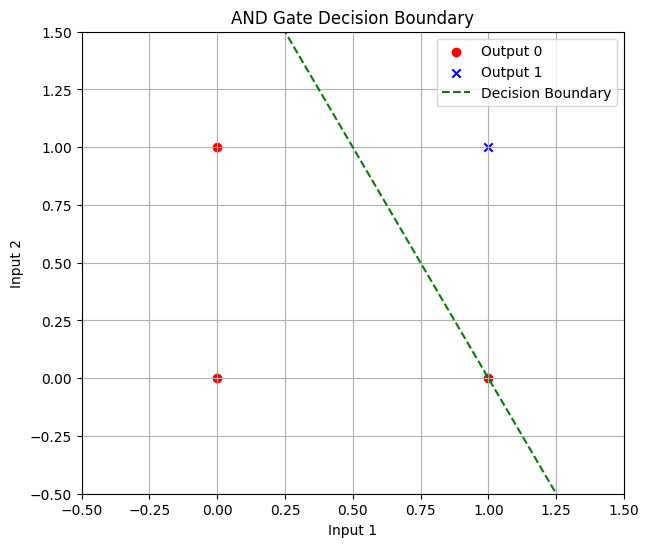

In [16]:
import matplotlib.pyplot as plt

# Create a figure and an axes object
plt.figure(figsize=(7, 6))
ax = plt.gca()

# Plot the training inputs, colored by their labels
# Points with label 0 (output 0)
ax.scatter(and_training_inputs[and_labels == 0, 0],
           and_training_inputs[and_labels == 0, 1],
           color='red', marker='o', label='Output 0')
# Points with label 1 (output 1)
ax.scatter(and_training_inputs[and_labels == 1, 0],
           and_training_inputs[and_labels == 1, 1],
           color='blue', marker='x', label='Output 1')

# Define the x-axis range for the decision boundary line
x_line = np.linspace(-0.5, 1.5, 100)

# Calculate the corresponding y-values for the decision boundary line
# The decision boundary is defined by w1*x1 + w2*x2 + bias = 0
# So, x2 = (-w1*x1 - bias) / w2
w1, w2 = perceptron_and.weights
bias = perceptron_and.bias

# Handle the case where w2 might be zero to prevent division by zero
if w2 != 0:
    y_line = (-w1 * x_line - bias) / w2
    ax.plot(x_line, y_line, color='green', linestyle='--', label='Decision Boundary')
else:
    # If w2 is zero, the boundary is a vertical line: w1*x1 + bias = 0 => x1 = -bias/w1
    if w1 != 0:
        x_vertical = -bias / w1
        ax.axvline(x=x_vertical, color='green', linestyle='--', label='Decision Boundary')
    else:
        # If both w1 and w2 are zero, no linear boundary (or trivial case)
        print("Cannot plot decision boundary: weights are both zero.")

# Set plot labels and title
ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_title('AND Gate Decision Boundary')
ax.legend()
ax.grid(True)

# Set axis limits for better visualization
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.5, 1.5])

plt.show()

**Reasoning**:
The previous step visualized the AND gate. Now, I will generate a plot for the OR gate, displaying the input points with different colors based on their labels (0 or 1) and drawing the linear decision boundary learned by the Perceptron using its weights and bias. This directly follows the overall task requirement to visualize both AND and OR gates.



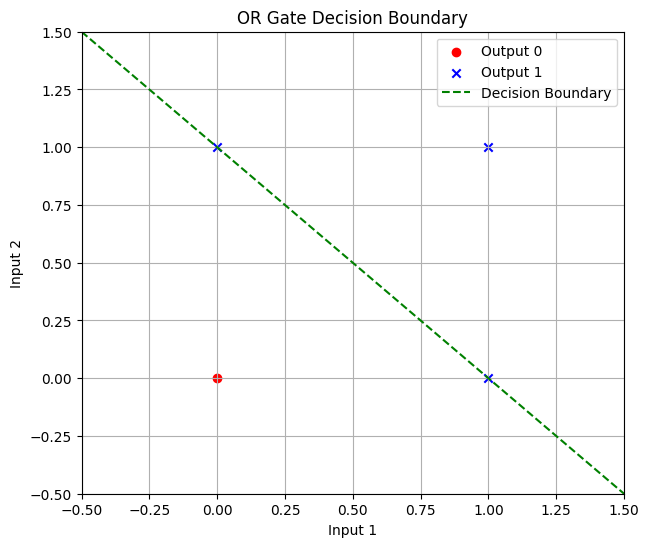

In [18]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the OR gate
plt.figure(figsize=(7, 6))
ax = plt.gca()

# Plot the training inputs, colored by their labels
# Points with label 0 (output 0)
ax.scatter(or_training_inputs[or_labels == 0, 0],
           or_training_inputs[or_labels == 0, 1],
           color='red', marker='o', label='Output 0')
# Points with label 1 (output 1)
ax.scatter(or_training_inputs[or_labels == 1, 0],
           or_training_inputs[or_labels == 1, 1],
           color='blue', marker='x', label='Output 1')

# Define the x-axis range for the decision boundary line
x_line_or = np.linspace(-0.5, 1.5, 100)

# Calculate the corresponding y-values for the decision boundary line
# The decision boundary is defined by w1*x1 + w2*x2 + bias = 0
# So, x2 = (-w1*x1 - bias) / w2
w1_or, w2_or = perceptron_or.weights
bias_or = perceptron_or.bias

# Handle the case where w2_or might be zero to prevent division by zero
if w2_or != 0:
    y_line_or = (-w1_or * x_line_or - bias_or) / w2_or
    ax.plot(x_line_or, y_line_or, color='green', linestyle='--', label='Decision Boundary')
else:
    # If w2 is zero, the boundary is a vertical line: w1*x1 + bias = 0 => x1 = -bias/w1
    if w1_or != 0:
        x_vertical_or = -bias_or / w1_or
        ax.axvline(x=x_vertical_or, color='green', linestyle='--', label='Decision Boundary')
    else:
        # If both w1 and w2 are zero, no linear boundary (or trivial case)
        print("Cannot plot decision boundary for OR gate: weights are both zero.")

# Set plot labels and title
ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_title('OR Gate Decision Boundary')
ax.legend()
ax.grid(True)

# Set axis limits for better visualization
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.5, 1.5])

plt.show()

## 4) Implementation of XOR Problem using PyTorch Neural Network.

# Task
Define a simple PyTorch neural network model with an input layer, a hidden layer, and an output layer suitable for the XOR problem.

## Define PyTorch XOR Model

### Subtask:
Define a simple PyTorch neural network model with an input layer, a hidden layer, and an output layer suitable for the XOR problem.


**Reasoning**:
The subtask is to define a PyTorch neural network model for the XOR problem. This step will implement the `XORNet` class, inheriting from `torch.nn.Module`, with an input layer, a hidden layer with a ReLU activation, and an output layer, as specified in the instructions.



In [19]:
import torch
import torch.nn as nn

# Define the XOR neural network model
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input layer (2 features) to hidden layer (4 features)
        self.hidden = nn.Linear(2, 4)
        # Output layer (4 features) to output (1 feature)
        self.output = nn.Linear(4, 1)
        # Activation function for the hidden layer
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass input through hidden layer and apply ReLU activation
        x = self.relu(self.hidden(x))
        # Pass through the output layer
        x = self.output(x)
        return x

print("XORNet model defined successfully.")

XORNet model defined successfully.


## Prepare XOR Data

### Subtask:
Define the XOR training inputs and corresponding labels as PyTorch tensors.


**Reasoning**:
I need to define the XOR training inputs and labels as NumPy arrays, then convert them to PyTorch tensors with the specified data types and shapes, as instructed in the subtask.



In [20]:
import numpy as np
import torch

# 1. Define the XOR training inputs as a NumPy array
xor_training_inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# 2. Define the XOR corresponding labels as a NumPy array
xor_labels = np.array([0, 1, 1, 0])

# 3. Convert the training inputs NumPy array to a PyTorch tensor
x_train = torch.tensor(xor_training_inputs, dtype=torch.float32)

# 4. Convert the labels NumPy array to a PyTorch tensor and reshape to (num_samples, 1)
y_train = torch.tensor(xor_labels, dtype=torch.float32).reshape(-1, 1)

print("XOR Training Inputs (PyTorch Tensor):\n", x_train)
print("Shape of x_train:", x_train.shape)
print("XOR Labels (PyTorch Tensor):\n", y_train)
print("Shape of y_train:", y_train.shape)

XOR Training Inputs (PyTorch Tensor):
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
Shape of x_train: torch.Size([4, 2])
XOR Labels (PyTorch Tensor):
 tensor([[0.],
        [1.],
        [1.],
        [0.]])
Shape of y_train: torch.Size([4, 1])


## Setup Loss and Optimizer

### Subtask:
Choose an appropriate loss function (e.g., Binary Cross Entropy) and an optimizer (e.g., SGD or Adam) for training the neural network.


**Reasoning**:
I need to instantiate the `XORNet` model, define the Binary Cross Entropy with Logits loss function, and set up the Adam optimizer with a learning rate of 0.01 for the model's parameters, as instructed by the subtask.



In [21]:
import torch.nn as nn
import torch.optim as optim

# Instantiate the XORNet model
model = XORNet()

# Define the loss function (Binary Cross Entropy with Logits for stability)
criterion = nn.BCEWithLogitsLoss()

# Define the optimizer (Adam with a learning rate of 0.01)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("XORNet model instantiated.")
print("Loss function (BCEWithLogitsLoss) defined.")
print("Optimizer (Adam) defined.")

XORNet model instantiated.
Loss function (BCEWithLogitsLoss) defined.
Optimizer (Adam) defined.


## Train the XOR Network

### Subtask:
Implement the training loop, performing forward passes, calculating loss, backpropagation, and weight updates over multiple epochs.


**Reasoning**:
I need to implement the training loop for the XOR network as described in the instructions, which includes forward pass, loss calculation, backpropagation, and weight updates over a specified number of epochs.



In [22]:
num_epochs = 10000

print("Starting XOR Network training...")

for epoch in range(num_epochs):
    # 1. Forward pass: Compute predicted y by passing x to the model
    outputs = model(x_train)

    # 2. Calculate loss: Compute and print loss
    loss = criterion(outputs, y_train)

    # 3. Zero gradients, perform a backward pass, and update the weights
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update weights

    # 4. Print loss every 1000 epochs
    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training finished.")

Starting XOR Network training...
Epoch [1000/10000], Loss: 0.0084
Epoch [2000/10000], Loss: 0.0018
Epoch [3000/10000], Loss: 0.0007
Epoch [4000/10000], Loss: 0.0003
Epoch [5000/10000], Loss: 0.0002
Epoch [6000/10000], Loss: 0.0001
Epoch [7000/10000], Loss: 0.0000
Epoch [8000/10000], Loss: 0.0000
Epoch [9000/10000], Loss: 0.0000
Epoch [10000/10000], Loss: 0.0000
Training finished.


## Evaluate and Predict

### Subtask:
Evaluate the trained model's performance on the XOR training data and make predictions.


**Reasoning**:
The subtask requires evaluating the trained XOR model. I will set the model to evaluation mode, make predictions on the training data, convert probabilities to binary outputs, and then display these predictions alongside the actual labels.



In [23]:
# 1. Set the model to evaluation mode
model.eval()

# 2. Disable gradient calculations for inference
with torch.no_grad():
    # 3. Perform a forward pass on the x_train data
    outputs = model(x_train)

    # 4. Apply a sigmoid activation function to convert logits to probabilities
    probabilities = torch.sigmoid(outputs)

    # 5. Convert probabilities into binary predictions (0 or 1) using a threshold of 0.5
    predictions = (probabilities >= 0.5).int()

# 6. Print the predicted outputs and compare them with the actual y_train labels
print("\n--- XOR Model Predictions ---")
for i in range(len(x_train)):
    print(f"Input: {x_train[i].numpy()}, Actual: {y_train[i].item()}, Predicted: {predictions[i].item()}")

# Calculate accuracy
correct_predictions = (predictions == y_train).sum().item()
total_predictions = len(y_train)
accuracy = correct_predictions / total_predictions
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")


--- XOR Model Predictions ---
Input: [0. 0.], Actual: 0.0, Predicted: 0
Input: [0. 1.], Actual: 1.0, Predicted: 1
Input: [1. 0.], Actual: 1.0, Predicted: 1
Input: [1. 1.], Actual: 0.0, Predicted: 0

Model Accuracy: 100.00%


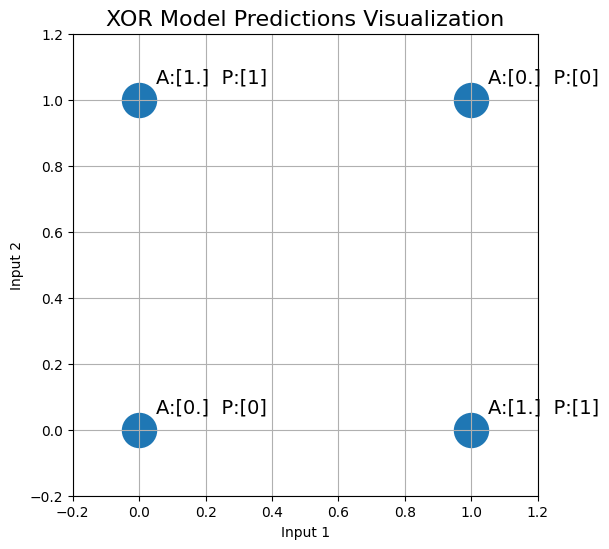

In [24]:
import matplotlib.pyplot as plt

# Convert tensors to numpy arrays
x_np = x_train.numpy()
y_np = y_train.numpy()
pred_np = predictions.numpy()

# Create figure
plt.figure(figsize=(6, 6))

# Plot points
plt.scatter(x_np[:, 0], x_np[:, 1], s=600)

# Annotate with Actual vs Predicted values
for i in range(len(x_np)):
    plt.annotate(
        f"A:{y_np[i]}  P:{pred_np[i]}",
        (x_np[i][0] + 0.05, x_np[i][1] + 0.05),
        fontsize=14
    )

# Formatting
plt.title("XOR Model Predictions Visualization", fontsize=16)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.grid(True)

plt.show()


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------------------------------
# Load CSV
# -------------------------------------------------------
df = pd.read_csv("house.csv")

# Extract features and label
X = torch.tensor(df[['bedrooms', 'sqft_living']].values, dtype=torch.float32)
y = torch.tensor(df[['price']].values, dtype=torch.float32)


In [29]:
# Normalize inputs
X_mean = X.mean(0, keepdim=True)
X_std = X.std(0, keepdim=True)
X_norm = (X - X_mean) / X_std

# Normalize target
y_mean = y.mean()
y_std = y.std()
y_norm = (y - y_mean) / y_std


In [30]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)   # 2 inputs → 2 hidden neurons
        self.output = nn.Linear(2, 1)   # 2 hidden → 1 output neuron
        self.act = nn.ReLU()

    def forward(self, x):
        h = self.act(self.hidden(x))
        out = self.output(h)
        return out

model = SimpleNN()


In [33]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 10000
losses = []


In [34]:
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_norm)
    loss = criterion(y_pred, y_norm)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 0.4903
Epoch 200, Loss: 0.4821
Epoch 400, Loss: 0.4810
Epoch 600, Loss: 0.4807
Epoch 800, Loss: 0.4807
Epoch 1000, Loss: 0.4807
Epoch 1200, Loss: 0.4807
Epoch 1400, Loss: 0.4808
Epoch 1600, Loss: 0.4807
Epoch 1800, Loss: 0.4807
Epoch 2000, Loss: 0.4807
Epoch 2200, Loss: 0.4807
Epoch 2400, Loss: 0.4807
Epoch 2600, Loss: 0.4807
Epoch 2800, Loss: 0.4808
Epoch 3000, Loss: 0.4807
Epoch 3200, Loss: 0.4807
Epoch 3400, Loss: 0.4807
Epoch 3600, Loss: 0.4807
Epoch 3800, Loss: 0.4807
Epoch 4000, Loss: 0.4807
Epoch 4200, Loss: 0.4807
Epoch 4400, Loss: 0.4807
Epoch 4600, Loss: 0.4807
Epoch 4800, Loss: 0.4808
Epoch 5000, Loss: 0.4807
Epoch 5200, Loss: 0.4807
Epoch 5400, Loss: 0.4807
Epoch 5600, Loss: 0.4807
Epoch 5800, Loss: 0.4808
Epoch 6000, Loss: 0.4807
Epoch 6200, Loss: 0.4807
Epoch 6400, Loss: 0.4807
Epoch 6600, Loss: 0.4807
Epoch 6800, Loss: 0.4807
Epoch 7000, Loss: 0.4808
Epoch 7200, Loss: 0.4807
Epoch 7400, Loss: 0.4807
Epoch 7600, Loss: 0.4807
Epoch 7800, Loss: 0.4807
Epoch 8

In [35]:
with torch.no_grad():
    pred_norm = model(X_norm)
    preds = pred_norm * y_std + y_mean   # de-normalize to dollars

print("\n--- Actual vs Predicted Prices ---")
for i in range(len(df)):
    print(f"Bedrooms: {df.bedrooms[i]}, "
          f"Sqft: {df.sqft_living[i]}, "
          f"Actual: {df.price[i]}, "
          f"Predicted: {preds[i].item():.2f}")



--- Actual vs Predicted Prices ---
Bedrooms: 3, Sqft: 1340, Actual: 313000, Predicted: 347532.31
Bedrooms: 5, Sqft: 3650, Actual: 2384000, Predicted: 935752.50
Bedrooms: 3, Sqft: 1930, Actual: 342000, Predicted: 510125.19
Bedrooms: 3, Sqft: 2000, Actual: 420000, Predicted: 529415.75
Bedrooms: 4, Sqft: 1940, Actual: 550000, Predicted: 488695.03
Bedrooms: 2, Sqft: 880, Actual: 490000, Predicted: 244951.00
Bedrooms: 2, Sqft: 1350, Actual: 335000, Predicted: 374473.91
Bedrooms: 4, Sqft: 2710, Actual: 482000, Predicted: 700892.38
Bedrooms: 3, Sqft: 2430, Actual: 452500, Predicted: 647915.62
Bedrooms: 4, Sqft: 1520, Actual: 640000, Predicted: 372951.06
Bedrooms: 3, Sqft: 1710, Actual: 463000, Predicted: 449497.31
Bedrooms: 4, Sqft: 2920, Actual: 1400000, Predicted: 758764.38
Bedrooms: 3, Sqft: 2330, Actual: 588500, Predicted: 620357.38
Bedrooms: 3, Sqft: 1090, Actual: 365000, Predicted: 278636.94
Bedrooms: 5, Sqft: 2910, Actual: 1200000, Predicted: 731822.62
Bedrooms: 3, Sqft: 1200, Actual:

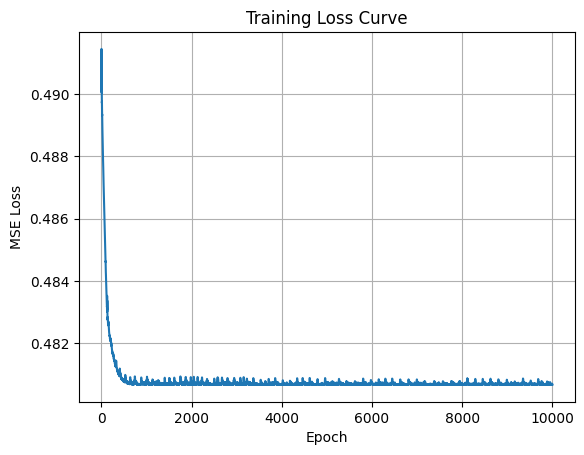

In [36]:
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


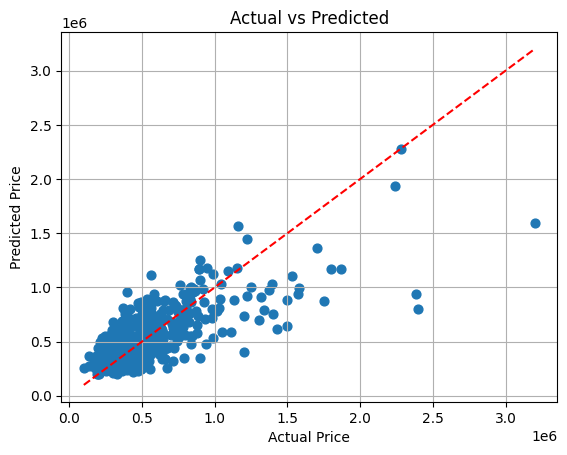

In [37]:
plt.scatter(df['price'], preds.numpy(), s=40)
plt.plot([df['price'].min(), df['price'].max()],
         [df['price'].min(), df['price'].max()],
         'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()


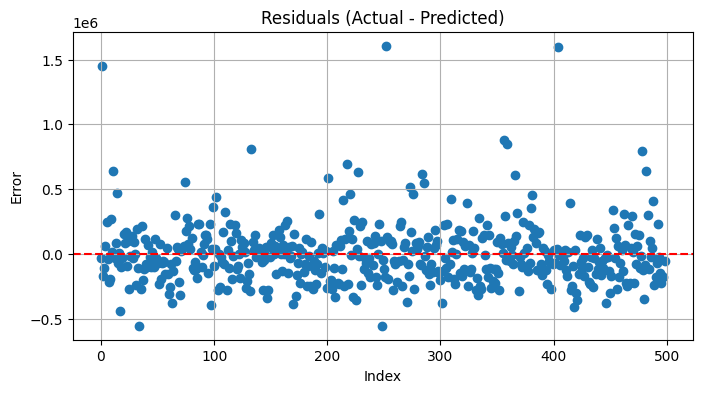

In [38]:
residuals = df['price'].values - preds.numpy().flatten()

plt.figure(figsize=(8,4))
plt.scatter(range(len(residuals)), residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Index")
plt.ylabel("Error")
plt.grid(True)
plt.show()
